In [ ]:
# Install ultralytics (YOLOv8 framework)
!pip install -q ultralytics

import torch
import os
import sys

# Uncomment the line below when running in Colab to verify GPU
!nvidia-smi

print("\n Environment ready!")

Sat May 23 13:51:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             33W /   70W |     385MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

print("=" * 60)
print("  CELL 2: Upload & Extract Dataset")
print("=" * 60)

#from google.colab import drive
#drive.mount('/content/drive')
zip_name = '/content/drive/MyDrive/Tobacco leaf disease detection.v1i.multiclass.zip'

# --- Unzip the dataset ---
import zipfile
import os

# Set the zip filename (adjust if your file has a different name)
#zip_name = "Tobacco leaf disease detection.v1i.multiclass.zip"
extract_dir = "dataset_raw"

if os.path.exists(extract_dir):
    print(f"'{extract_dir}' already exists, skipping extraction.")
else:
    print(f"Extracting '{zip_name}' ...")
    # Uncomment the line below when running in Colab:
    !unzip -q "{zip_name}" -d {extract_dir}

    # Or use Python's zipfile (works everywhere):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted to '{extract_dir}/'")

# Verify extraction
for split in ['train', 'valid', 'test']:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        n_files = len([f for f in os.listdir(split_dir) if f.endswith('.jpg')])
        print(f"   {split:>5s}: {n_files} images")
    else:
        print(f"    {split} folder not found!")

print("\n Dataset extracted successfully!")

  CELL 2: Upload & Extract Dataset
📂 'dataset_raw' already exists, skipping extraction.
   train: 1052 images
   valid: 124 images
    test: 92 images

✅ Dataset extracted successfully!


In [ ]:
import pandas as pd
import shutil
import os
from pathlib import Path

print("=" * 60)
print("  CELL 3: Reorganize Dataset for YOLOv8 Classification")
print("=" * 60)

# ── Configuration ──────────────────────────────────────────────────────────
RAW_DIR = "dataset_raw"          # Where the ZIP was extracted
YOLO_DIR = "dataset_yolo"        # Output directory for YOLOv8-cls format

# Mapping from CSV column names → clean folder names
# The CSV columns have spaces and long names; we map them to short, clean names
CLASS_MAP = {
    'alternaria alternata': 'alternaria_alternata',
    'cercospora nicotianae': 'cercospora_nicotianae',
    'no cercospora nicotianae or alternaria alternata present': 'healthy'
}

# Roboflow uses "valid" but YOLOv8 expects "val"
SPLIT_MAP = {
    'train': 'train',
    'valid': 'val',
    'test': 'test'
}

# ── Reorganization Logic ──────────────────────────────────────────────────

def reorganize_split(raw_split_dir, yolo_split_dir, split_name):
    """
    Read _classes.csv from a split folder, determine each image's class
    from the one-hot encoding, and copy it to the appropriate class subfolder.

    CSV format example:
        filename, alternaria alternata, cercospora nicotianae, no cercospora...
        image1.jpg, 1, 0, 0
        image2.jpg, 0, 1, 0
        image3.jpg, 0, 0, 1
    """
    csv_path = os.path.join(raw_split_dir, '_classes.csv')

    if not os.path.exists(csv_path):
        print(f"    _classes.csv not found in {raw_split_dir}")
        return 0

    # Read the CSV — columns have leading spaces after the comma
    df = pd.read_csv(csv_path)

    # Strip whitespace from column names (Roboflow adds spaces after commas)
    df.columns = df.columns.str.strip()

    # Also strip the filename column values
    df['filename'] = df['filename'].str.strip()

    print(f"\n    {split_name}: Found {len(df)} entries in _classes.csv")

    # Create class subdirectories
    for csv_col, folder_name in CLASS_MAP.items():
        target_dir = os.path.join(yolo_split_dir, folder_name)
        os.makedirs(target_dir, exist_ok=True)

    # Process each image
    copied = 0
    skipped = 0
    for idx, row in df.iterrows():
        filename = row['filename']
        src_path = os.path.join(raw_split_dir, filename)

        # Determine class from one-hot encoding
        # Find which column has value 1
        class_name = None
        for csv_col, folder_name in CLASS_MAP.items():
            if csv_col in df.columns and int(row[csv_col]) == 1:
                class_name = folder_name
                break

        if class_name is None:
            print(f"       No class found for {filename}, skipping...")
            skipped += 1
            continue

        if not os.path.exists(src_path):
            # Try without extension issues
            skipped += 1
            continue

        # Copy image to class folder
        dst_path = os.path.join(yolo_split_dir, class_name, filename)
        shutil.copy2(src_path, dst_path)
        copied += 1

    print(f"      ✅ Copied {copied} images ({skipped} skipped)")
    return copied


# ── Execute Reorganization ────────────────────────────────────────────────

if os.path.exists(YOLO_DIR):
    print(f"🗑️  Removing existing '{YOLO_DIR}' directory...")
    shutil.rmtree(YOLO_DIR)

total_images = 0
for raw_split, yolo_split in SPLIT_MAP.items():
    raw_split_dir = os.path.join(RAW_DIR, raw_split)
    yolo_split_dir = os.path.join(YOLO_DIR, yolo_split)
    count = reorganize_split(raw_split_dir, yolo_split_dir, yolo_split)
    total_images += count

print(f"\n{'─' * 50}")
print(f"📊 Total images reorganized: {total_images}")
print(f"\n📁 New folder structure:")
for yolo_split in ['train', 'val', 'test']:
    split_path = os.path.join(YOLO_DIR, yolo_split)
    if os.path.exists(split_path):
        print(f"   {YOLO_DIR}/{yolo_split}/")
        for cls_folder in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls_folder)
            if os.path.isdir(cls_path):
                n = len(os.listdir(cls_path))
                print(f"      ├── {cls_folder}/  ({n} images)")

print("\n✅ Dataset reorganized for YOLOv8 classification!")


  CELL 3: Reorganize Dataset for YOLOv8 Classification
🗑️  Removing existing 'dataset_yolo' directory...

   📋 train: Found 1052 entries in _classes.csv
      ✅ Copied 1052 images (0 skipped)

   📋 val: Found 124 entries in _classes.csv
      ✅ Copied 124 images (0 skipped)

   📋 test: Found 92 entries in _classes.csv
      ✅ Copied 92 images (0 skipped)

──────────────────────────────────────────────────
📊 Total images reorganized: 1268

📁 New folder structure:
   dataset_yolo/train/
      ├── alternaria_alternata/  (350 images)
      ├── cercospora_nicotianae/  (453 images)
      ├── healthy/  (249 images)
   dataset_yolo/val/
      ├── alternaria_alternata/  (32 images)
      ├── cercospora_nicotianae/  (52 images)
      ├── healthy/  (40 images)
   dataset_yolo/test/
      ├── alternaria_alternata/  (28 images)
      ├── cercospora_nicotianae/  (20 images)
      ├── healthy/  (44 images)

✅ Dataset reorganized for YOLOv8 classification!


  CELL 4: Data Exploration & Visualization

📊 Image counts per class per split:
Class                       Train     Val    Test   Total
───────────────────────────────────────────────────────
Alternaria alternata          350      32      28     410
Cercospora nicotianae         453      52      20     525
Healthy                       249      40      44     333
───────────────────────────────────────────────────────
TOTAL                        1052     124      92    1268


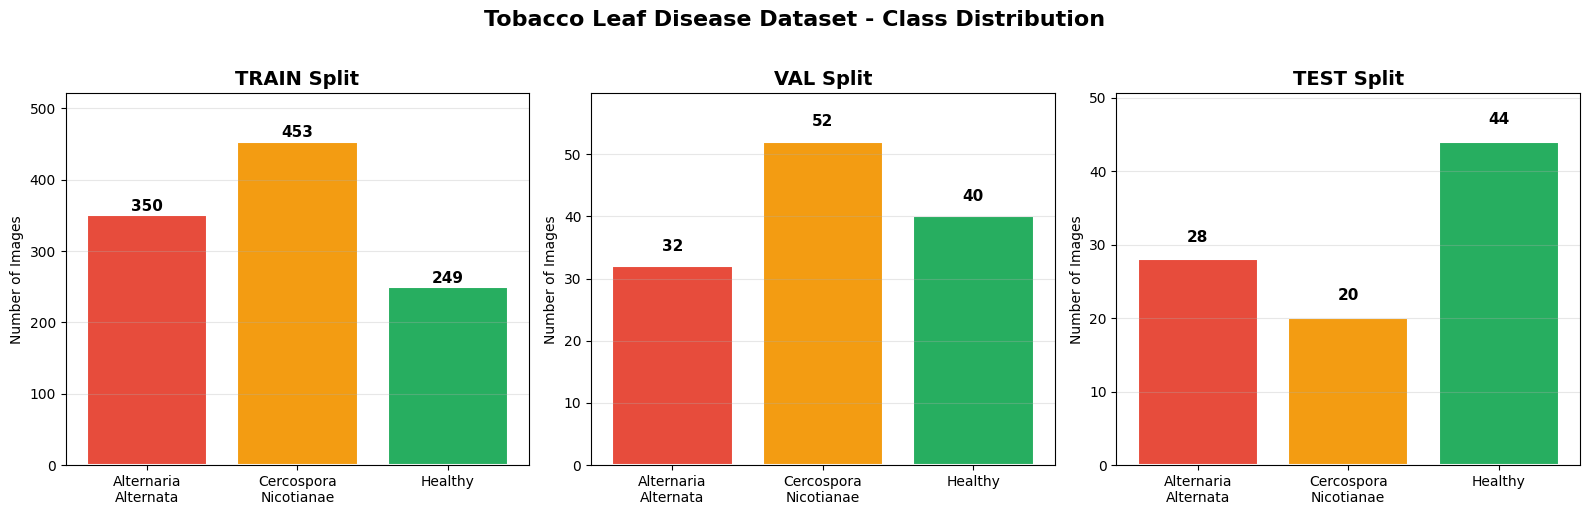

   💾 Saved: class_distribution.png


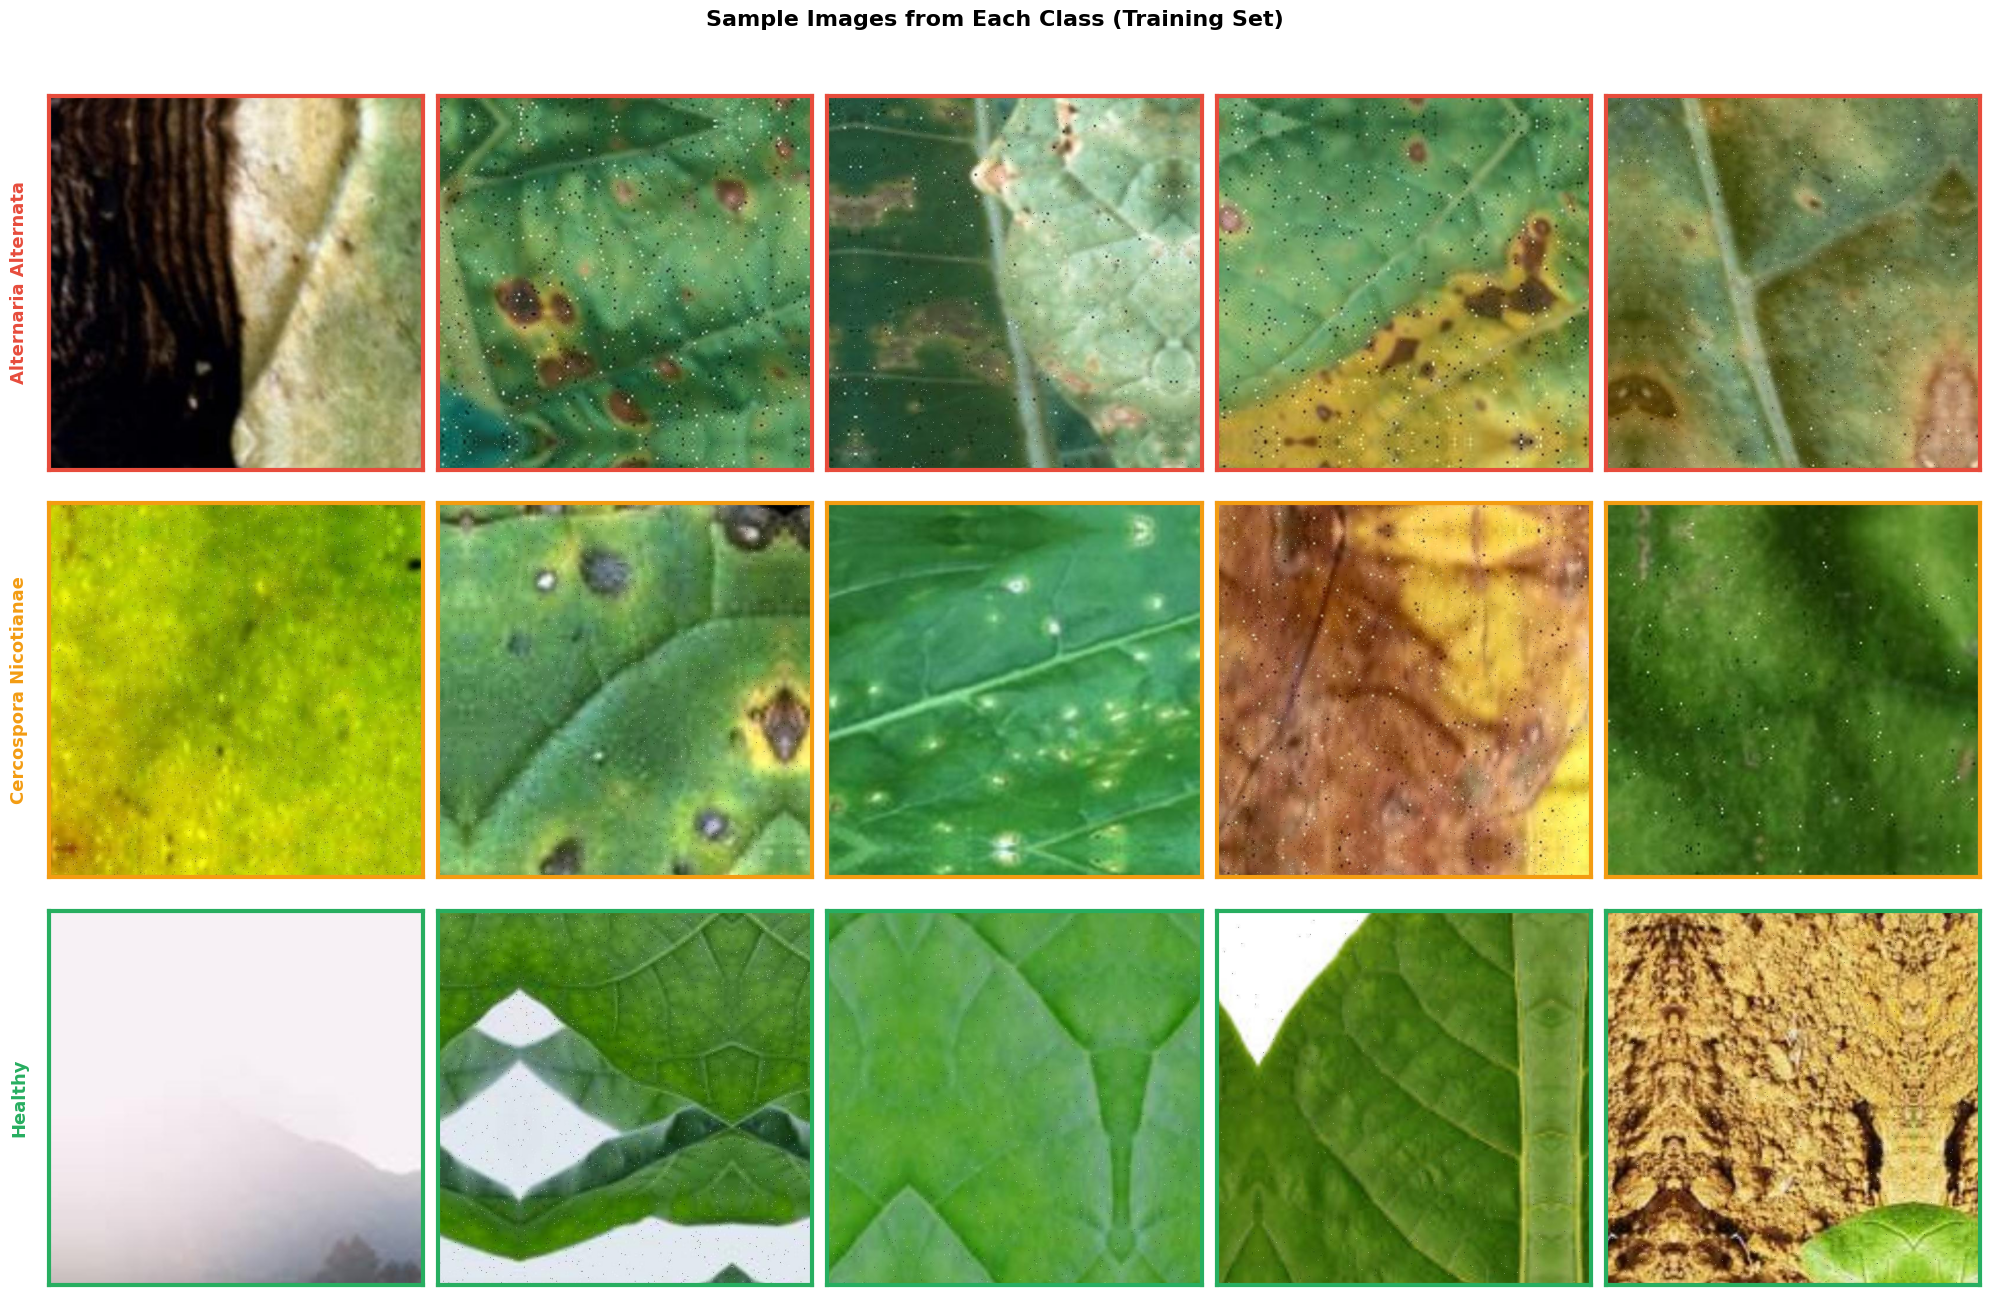

   💾 Saved: sample_images.png

✅ Data exploration complete!


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import random

print("=" * 60)
print("  CELL 4: Data Exploration & Visualization")
print("=" * 60)

YOLO_DIR = "dataset_yolo"
CLASS_NAMES = ['alternaria_alternata', 'cercospora_nicotianae', 'healthy']
CLASS_DISPLAY = ['Alternaria\nAlternata', 'Cercospora\nNicotianae', 'Healthy']
COLORS = ['#e74c3c', '#f39c12', '#27ae60']  # Red, Orange, Green

# ── 4a: Count images per class per split ──────────────────────────────────
print("\n📊 Image counts per class per split:")
print(f"{'Class':<25s} {'Train':>7s} {'Val':>7s} {'Test':>7s} {'Total':>7s}")
print("─" * 55)

split_counts = {}
for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(YOLO_DIR, split, cls)
        if os.path.exists(cls_dir):
            count = len([f for f in os.listdir(cls_dir)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            count = 0
        split_counts[split][cls] = count

for cls, display in zip(CLASS_NAMES, ['Alternaria alternata', 'Cercospora nicotianae', 'Healthy']):
    train_n = split_counts['train'].get(cls, 0)
    val_n = split_counts['val'].get(cls, 0)
    test_n = split_counts['test'].get(cls, 0)
    total = train_n + val_n + test_n
    print(f"{display:<25s} {train_n:>7d} {val_n:>7d} {test_n:>7d} {total:>7d}")

total_train = sum(split_counts['train'].values())
total_val = sum(split_counts['val'].values())
total_test = sum(split_counts['test'].values())
print("─" * 55)
print(f"{'TOTAL':<25s} {total_train:>7d} {total_val:>7d} {total_test:>7d} {total_train+total_val+total_test:>7d}")

# ── 4b: Class distribution bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, split in enumerate(['train', 'val', 'test']):
    counts = [split_counts[split].get(cls, 0) for cls in CLASS_NAMES]
    bars = axes[idx].bar(CLASS_DISPLAY, counts, color=COLORS, edgecolor='white', linewidth=1.5)
    axes[idx].set_title(f'{split.upper()} Split', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Number of Images')

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                      str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)

    axes[idx].set_ylim(0, max(counts) * 1.15)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Tobacco Leaf Disease Dataset - Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("   💾 Saved: class_distribution.png")

# ── 4c: Sample images grid ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 13))

for row_idx, (cls, display_name, color) in enumerate(
    zip(CLASS_NAMES, ['Alternaria Alternata', 'Cercospora Nicotianae', 'Healthy'], COLORS)):

    cls_dir = os.path.join(YOLO_DIR, 'train', cls)
    if os.path.exists(cls_dir):
        images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_images = random.sample(images, min(5, len(images)))
    else:
        sample_images = []

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_images):
            img_path = os.path.join(cls_dir, sample_images[col_idx])
            img = mpimg.imread(img_path)
            ax.imshow(img)
            # Add colored border
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
        else:
            ax.axis('off')
            continue

        ax.set_xticks([])
        ax.set_yticks([])

        # Add class label on first column
        if col_idx == 0:
            ax.set_ylabel(display_name, fontsize=13, fontweight='bold',
                         color=color, rotation=90, labelpad=15)

plt.suptitle('Sample Images from Each Class (Training Set)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("   💾 Saved: sample_images.png")

print("\n✅ Data exploration complete!")

In [ ]:
from ultralytics import YOLO

print("=" * 60)
print("  CELL 5: Train YOLOv8 Classification Model")
print("=" * 60)

# ── Load the pre-trained YOLOv8 nano classification model ─────────────────
# We use the nano model (yolov8n-cls) because:
#   - It's fast to train on Colab's free T4 GPU
#   - It's small enough for mobile/edge deployment
#   - With only 3 classes and ~1200 images, a larger model would overfit
model = YOLO('yolov8n-cls.pt')

print("\n Starting training...")
print("   This will take approximately 15-30 minutes on a T4 GPU.\n")

# ── Training configuration ────────────────────────────────────────────────
results = model.train(
    data='dataset_yolo',           # Path to reorganized dataset
    epochs=50,                     # Number of training epochs
    imgsz=224,                     # Input image size (224 is standard for cls)
    batch=32,                      # Batch size (32 works well on T4's 16GB)
    patience=10,                   # Early stopping: stop if no improvement for 10 epochs
    optimizer='AdamW',             # AdamW optimizer (good default)
    lr0=0.001,                     # Initial learning rate
    lrf=0.01,                      # Final learning rate factor (lr0 * lrf)
    weight_decay=0.0005,           # L2 regularization
    warmup_epochs=3,               # Warm-up epochs for learning rate
    augment=True,                  # Enable data augmentation
    hsv_h=0.015,                   # HSV-Hue augmentation range
    hsv_s=0.7,                     # HSV-Saturation augmentation range
    hsv_v=0.4,                     # HSV-Value augmentation range
    degrees=15.0,                  # Random rotation ±15 degrees
    translate=0.1,                 # Random translation ±10%
    scale=0.5,                     # Random scale ±50%
    flipud=0.1,                    # Vertical flip probability (low - leaves have orientation)
    fliplr=0.5,                    # Horizontal flip probability
    mosaic=0.0,                    # Disable mosaic (not ideal for classification)
    name='tobacco_disease_cls',    # Experiment name
    project='/content/drive/MyDrive/runs/classify',       # Output directory
    exist_ok=True,                 # Overwrite if exists
    verbose=True,                  # Print detailed logs
    seed=42,                       # Reproducibility
)

print("\n" + "=" * 60)
print("✅ Training complete!")
print(f"   Best model saved to: runs/classify/tobacco_disease_cls/weights/best.pt")
print(f"   Last model saved to: runs/classify/tobacco_disease_cls/weights/last.pt")
print("=" * 60)


  CELL 5: Train YOLOv8 Classification Model

 Starting training...
   This will take approximately 15-30 minutes on a T4 GPU.

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=0.0, multi_scal

  CELL 6: Evaluate Model Performance
✅ Loaded best model from: /content/drive/MyDrive/runs/classify/tobacco_disease_cls/weights/best.pt

📊 Running validation...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset_yolo/train... found 1052 images in 3 classes ✅ 
val: /content/dataset_yolo/val... found 124 images in 3 classes ✅ 
test: /content/dataset_yolo/test... found 92 images in 3 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 959.4±441.8 MB/s, size: 43.5 KB)
val: Scanning /content/dataset_yolo/val... 124 images, 0 corrupt: 100% ━━━━━━━━━━━━ 124/124 43.3Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 7.0it/s 1.1s
                   all      0.927          1
Speed: 1.0ms preprocess, 4.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

────────────────────

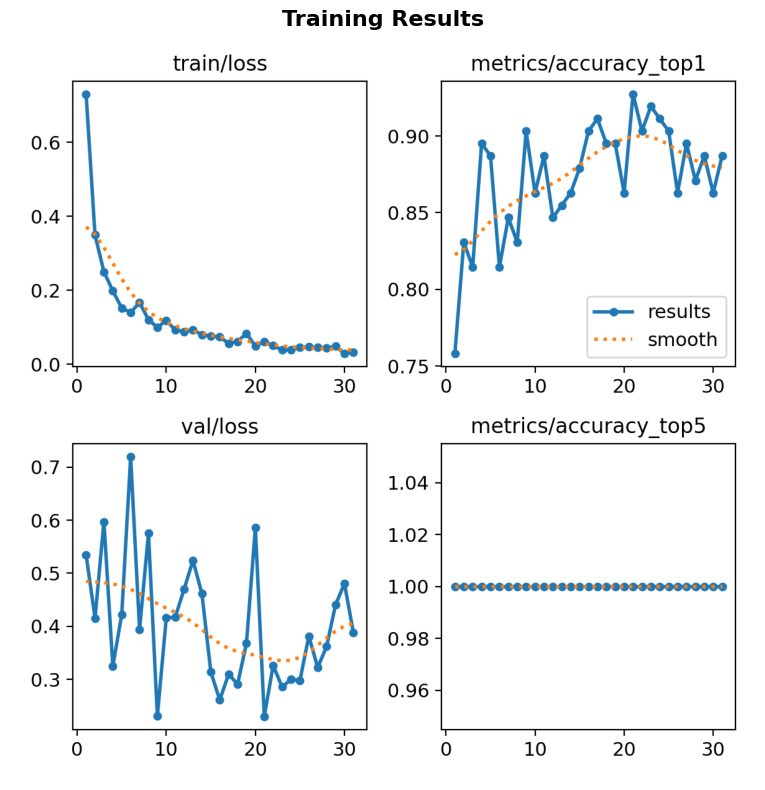

   📈 Training curves displayed above


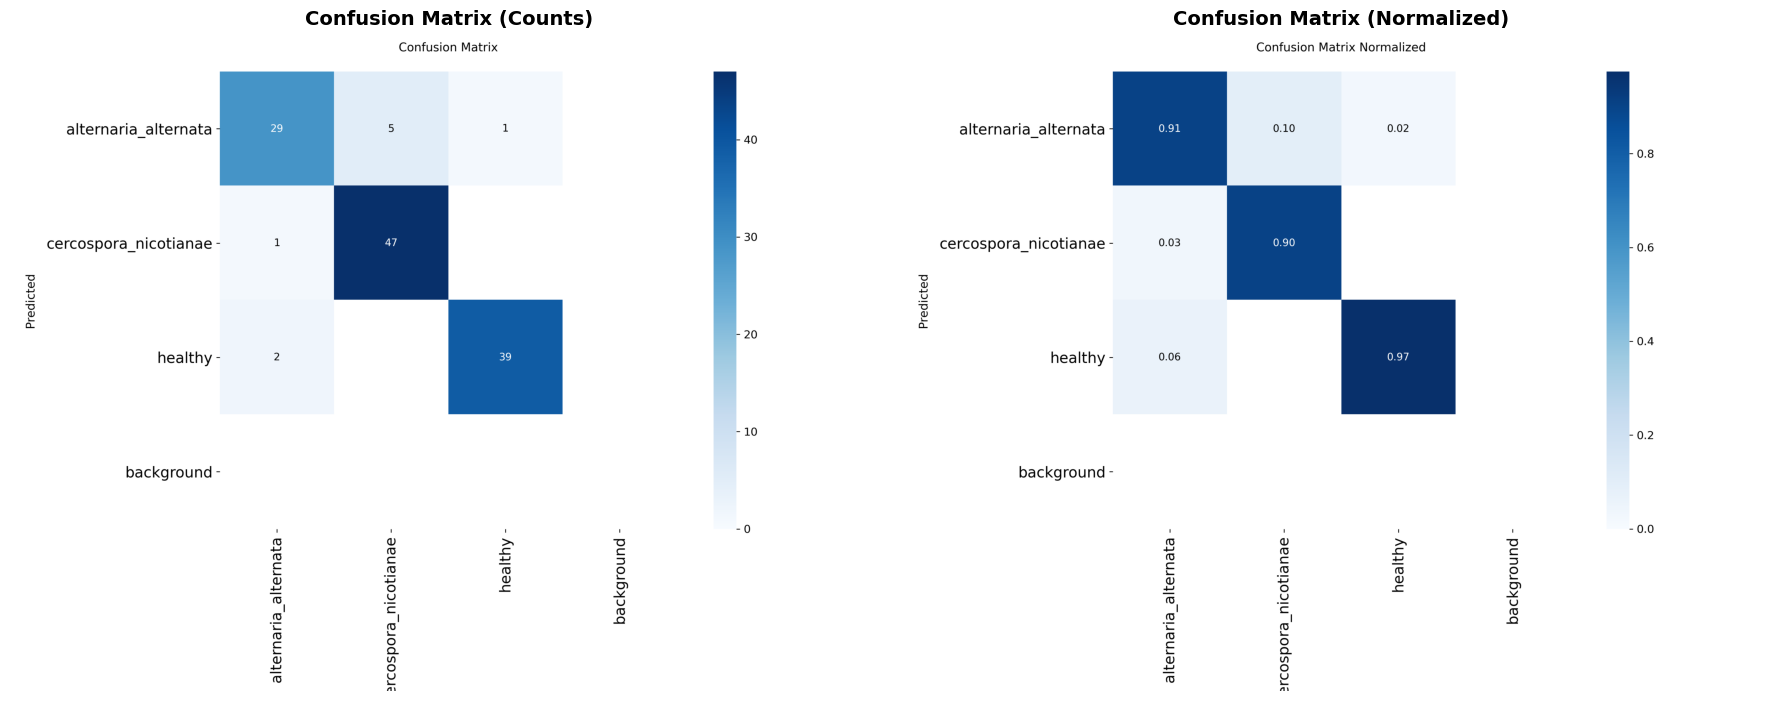

   💾 Saved: confusion_matrices.png

✅ Evaluation complete!


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

print("=" * 60)
print("  CELL 6: Evaluate Model Performance")
print("=" * 60)

# ── Load the best model ──────────────────────────────────────────────────
best_model_path = '/content/drive/MyDrive/runs/classify/tobacco_disease_cls/weights/best.pt'
model = YOLO(best_model_path)
print(f"✅ Loaded best model from: {best_model_path}")

# ── Run validation on the validation set ──────────────────────────────────
print("\n📊 Running validation...")
metrics = model.val()

# ── Print key metrics ────────────────────────────────────────────────────
print("\n" + "─" * 50)
print("📈 VALIDATION RESULTS")
print("─" * 50)

# Top-1 and Top-5 accuracy
top1 = metrics.top1
top5 = metrics.top5
print(f"   Top-1 Accuracy: {top1:.4f} ({top1*100:.1f}%)")
print(f"   Top-5 Accuracy: {top5:.4f} ({top5*100:.1f}%)")
print("─" * 50)

# ── Display training curves ──────────────────────────────────────────────
results_dir = '/content/drive/MyDrive/runs/classify/tobacco_disease_cls'

# Show training results plot (generated by YOLO)
results_img = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img):
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    img = mpimg.imread(results_img)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("   📈 Training curves displayed above")

# ── Display confusion matrix ─────────────────────────────────────────────
cm_img = os.path.join(results_dir, 'confusion_matrix.png')
cm_norm_img = os.path.join(results_dir, 'confusion_matrix_normalized.png')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, img_path, title in [
    (axes[0], cm_img, 'Confusion Matrix (Counts)'),
    (axes[1], cm_norm_img, 'Confusion Matrix (Normalized)')
]:
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Not found:\n{img_path}', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("   💾 Saved: confusion_matrices.png")

print("\n✅ Evaluation complete!")


  CELL 7: Test Predictions on Sample Images
   Found 92 test images


/tmp/ipykernel_1261/3986523460.py:128: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1261/3986523460.py:129: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


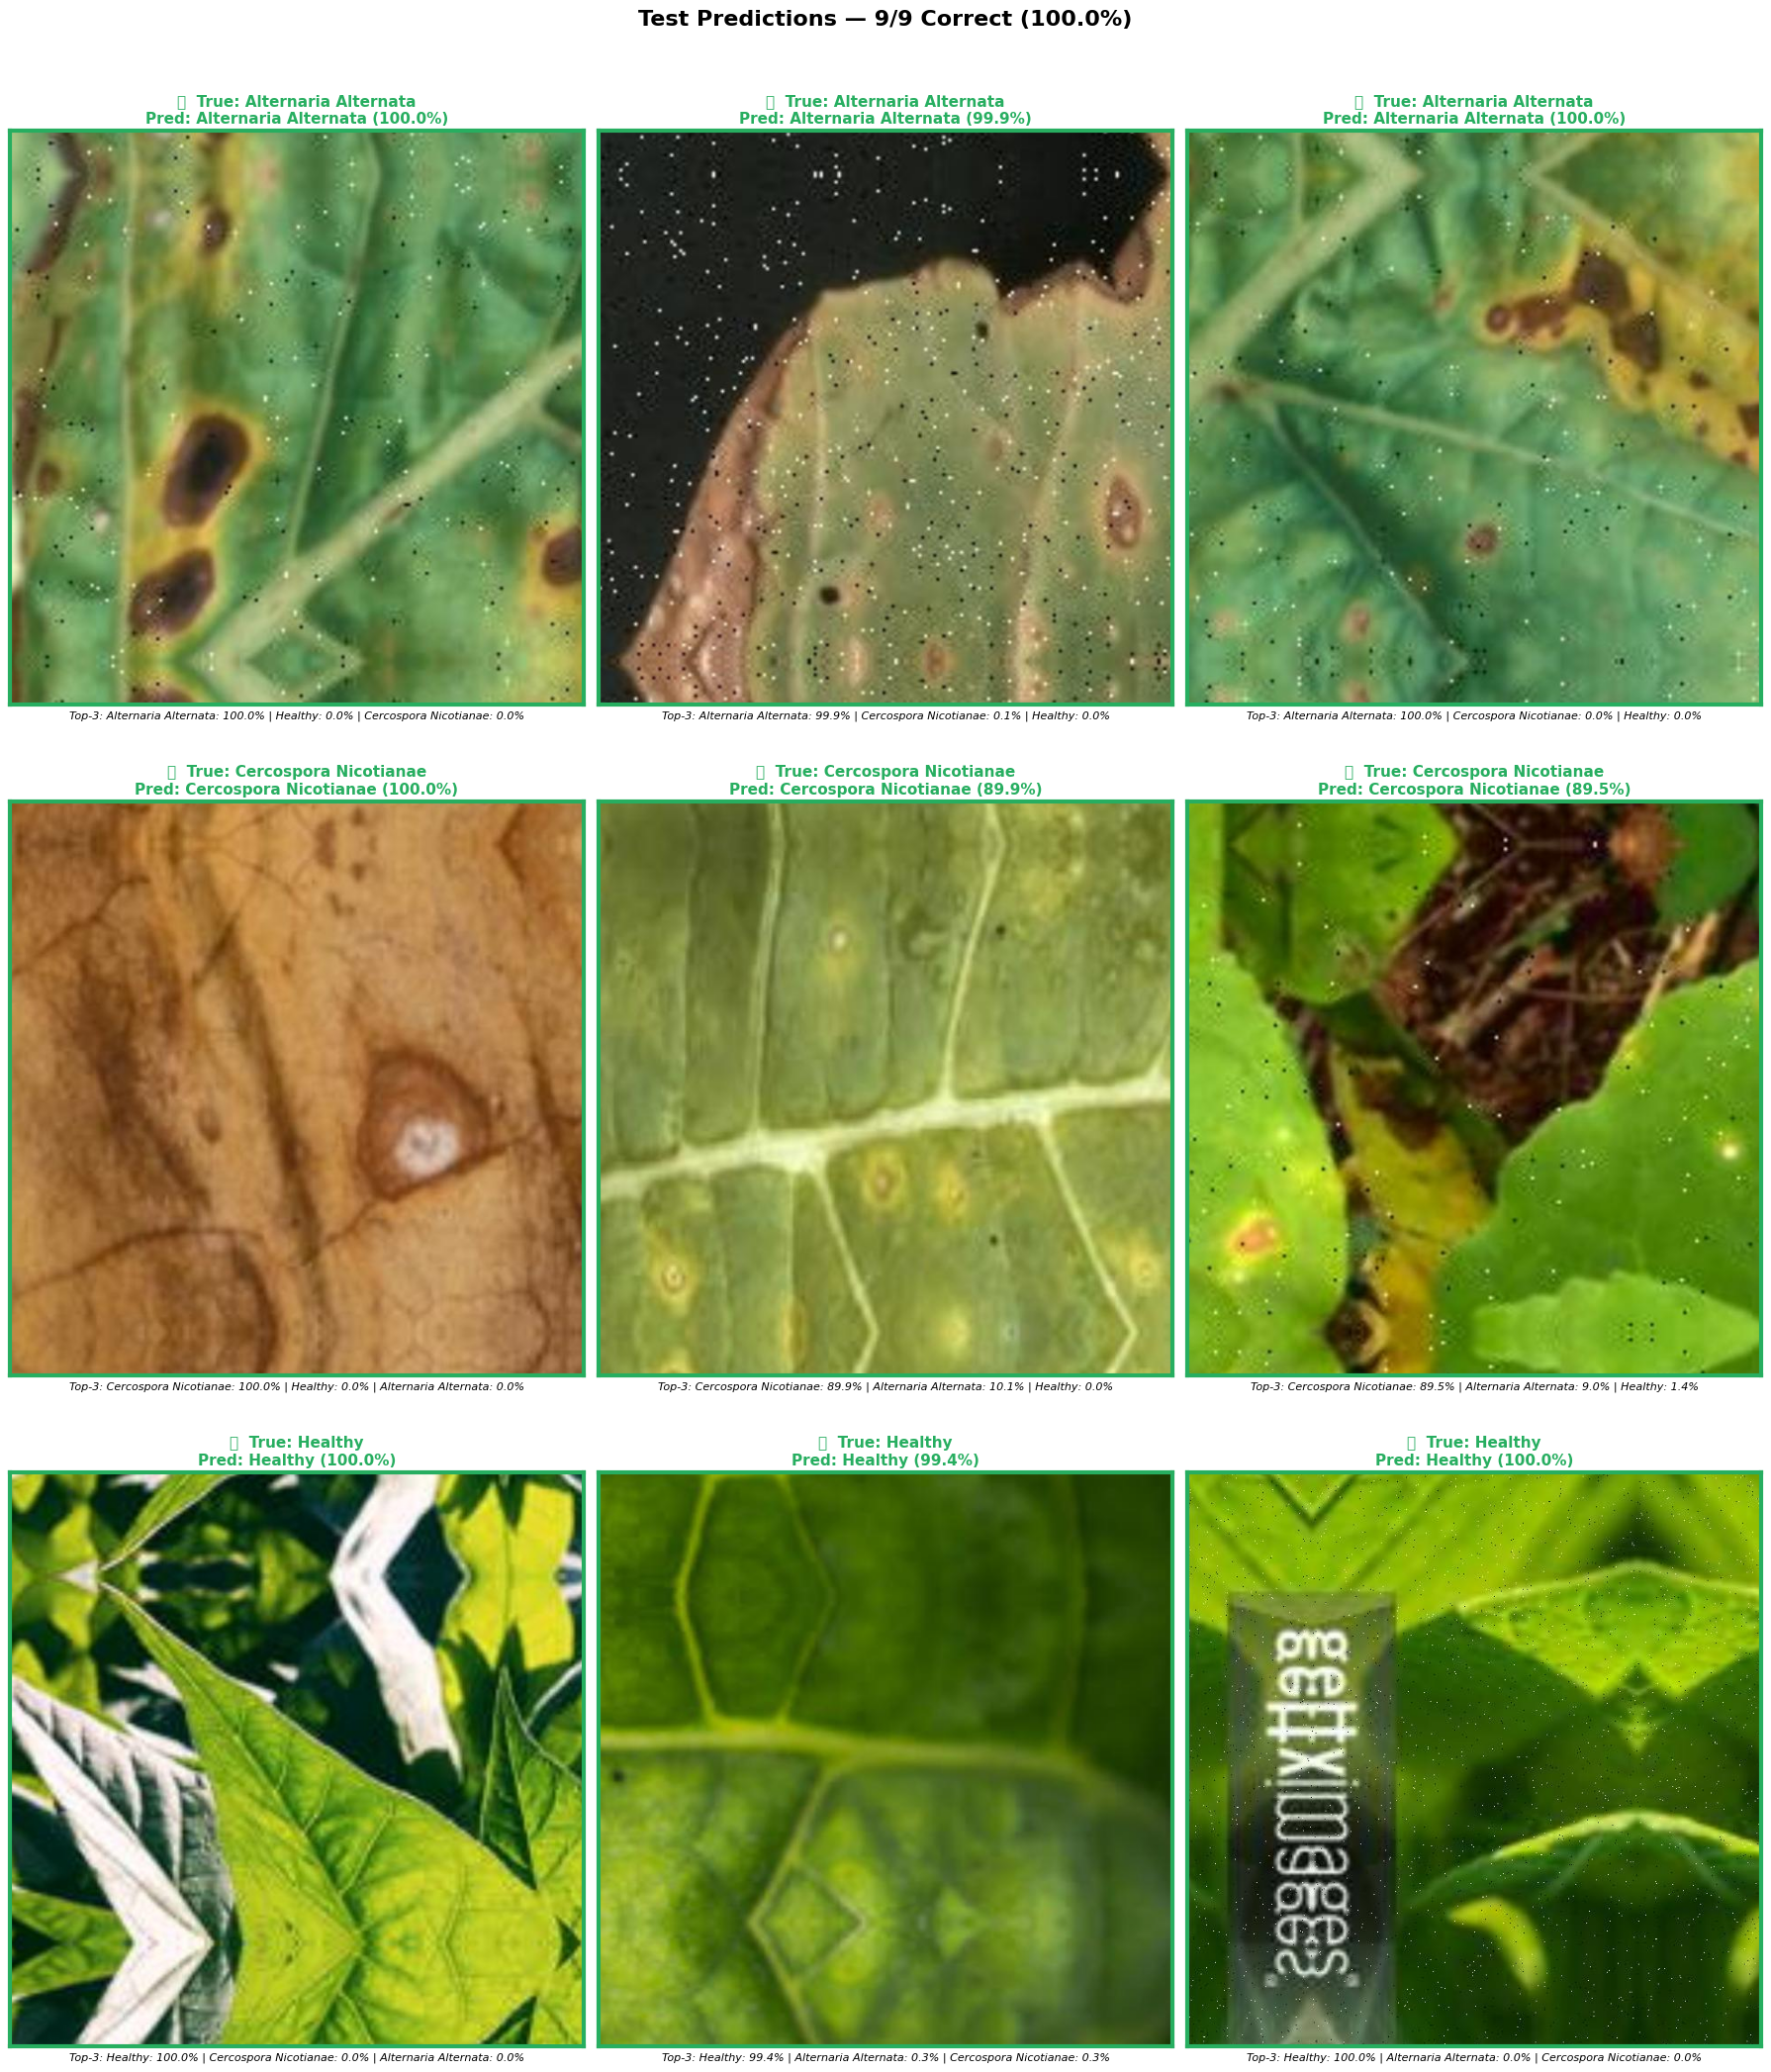


   🎯 Test sample accuracy: 9/9 (100.0%)
   💾 Saved: test_predictions.png

📊 Full test set evaluation:

   Class                      Correct   Total   Accuracy
   ────────────────────────────────────────────────────
   Alternaria Alternata            24      28      85.7%
   Cercospora Nicotianae           19      20      95.0%
   Healthy                         43      44      97.7%
   ────────────────────────────────────────────────────
   OVERALL                         86      92      93.5%

✅ Test predictions complete!


In [ ]:

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

print("=" * 60)
print("  CELL 7: Test Predictions on Sample Images")
print("=" * 60)

# ── Load model ───────────────────────────────────────────────────────────
model = YOLO('/content/drive/MyDrive/runs/classify/tobacco_disease_cls/weights/best.pt')

# ── Class info ───────────────────────────────────────────────────────────
CLASS_COLORS = {
    'alternaria_alternata': '#e74c3c',    # Red
    'cercospora_nicotianae': '#f39c12',   # Orange
    'healthy': '#27ae60'                   # Green
}

CLASS_DISPLAY_NAMES = {
    'alternaria_alternata': 'Alternaria Alternata',
    'cercospora_nicotianae': 'Cercospora Nicotianae',
    'healthy': 'Healthy'
}

# ── Gather test images with their true labels ─────────────────────────────
YOLO_DIR = "dataset_yolo"
test_images = []

for cls_name in ['alternaria_alternata', 'cercospora_nicotianae', 'healthy']:
    cls_dir = os.path.join(YOLO_DIR, 'test', cls_name)
    if os.path.exists(cls_dir):
        for img_file in os.listdir(cls_dir):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_images.append({
                    'path': os.path.join(cls_dir, img_file),
                    'true_class': cls_name
                })

print(f"   Found {len(test_images)} test images")

# ── Select random samples (3 from each class if possible) ────────────────
samples_per_class = 3
selected = []
for cls_name in ['alternaria_alternata', 'cercospora_nicotianae', 'healthy']:
    cls_images = [img for img in test_images if img['true_class'] == cls_name]
    n = min(samples_per_class, len(cls_images))
    selected.extend(random.sample(cls_images, n))

# ── Run predictions and visualize ────────────────────────────────────────
n_images = len(selected)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
if n_rows == 1:
    axes = [axes]
axes = np.array(axes).flatten()

correct = 0
total = 0

for idx, sample in enumerate(selected):
    ax = axes[idx]

    # Run prediction
    results = model(sample['path'], verbose=False)
    result = results[0]

    # Get prediction info
    probs = result.probs
    pred_class_idx = probs.top1
    pred_class = result.names[pred_class_idx]
    pred_conf = probs.top1conf.item()

    # Top-3 predictions
    top5_indices = probs.top5
    top5_confs = probs.top5conf.tolist()

    true_class = sample['true_class']
    is_correct = pred_class == true_class
    if is_correct:
        correct += 1
    total += 1

    # Display image
    img = mpimg.imread(sample['path'])
    ax.imshow(img)

    # Title with prediction info
    true_display = CLASS_DISPLAY_NAMES.get(true_class, true_class)
    pred_display = CLASS_DISPLAY_NAMES.get(pred_class, pred_class)
    status = "✅" if is_correct else "❌"

    title = f"{status}  True: {true_display}\nPred: {pred_display} ({pred_conf:.1%})"
    title_color = '#27ae60' if is_correct else '#e74c3c'
    ax.set_title(title, fontsize=11, fontweight='bold', color=title_color)

    # Add top-3 predictions as text below image
    top3_text = "Top-3: "
    for i, (t_idx, t_conf) in enumerate(zip(top5_indices[:3], top5_confs[:3])):
        cls = result.names[t_idx]
        display = CLASS_DISPLAY_NAMES.get(cls, cls)
        top3_text += f"{display}: {t_conf:.1%}"
        if i < 2:
            top3_text += " | "

    ax.set_xlabel(top3_text, fontsize=8, style='italic')
    ax.set_xticks([])
    ax.set_yticks([])

    # Border color
    border_color = '#27ae60' if is_correct else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

# Hide unused axes
for idx in range(len(selected), len(axes)):
    axes[idx].axis('off')

plt.suptitle(
    f'Test Predictions — {correct}/{total} Correct ({correct/total:.1%})',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n   🎯 Test sample accuracy: {correct}/{total} ({correct/total:.1%})")
print("   💾 Saved: test_predictions.png")

# ── Run full test set evaluation ─────────────────────────────────────────
print("\n📊 Full test set evaluation:")
all_test_paths = [img['path'] for img in test_images]
all_true_labels = [img['true_class'] for img in test_images]

full_correct = 0
class_correct = {cls: 0 for cls in CLASS_DISPLAY_NAMES}
class_total = {cls: 0 for cls in CLASS_DISPLAY_NAMES}

for img_info in test_images:
    results = model(img_info['path'], verbose=False)
    pred_class = results[0].names[results[0].probs.top1]
    true_class = img_info['true_class']

    class_total[true_class] += 1
    if pred_class == true_class:
        full_correct += 1
        class_correct[true_class] += 1

print(f"\n   {'Class':<25s} {'Correct':>8s} {'Total':>7s} {'Accuracy':>10s}")
print("   " + "─" * 52)
for cls in CLASS_DISPLAY_NAMES:
    display = CLASS_DISPLAY_NAMES[cls]
    c = class_correct[cls]
    t = class_total[cls]
    acc = c / t if t > 0 else 0
    print(f"   {display:<25s} {c:>8d} {t:>7d} {acc:>10.1%}")
print("   " + "─" * 52)
print(f"   {'OVERALL':<25s} {full_correct:>8d} {len(test_images):>7d} {full_correct/len(test_images):>10.1%}")

print("\n✅ Test predictions complete!")


In [ ]:

import shutil
import os

print("=" * 60)
print("  CELL 8: Export & Download Trained Model")
print("=" * 60)

# ── Copy best weights to accessible location ─────────────────────────────
src = '/content/drive/MyDrive/runs/classify/tobacco_disease_cls/weights/best.pt'
dst = '/content/drive/MyDrive/tobacco_disease_best.pt'

if os.path.exists(src):
    shutil.copy(src, dst)
    file_size = os.path.getsize(dst) / (1024 * 1024)
    print(f" Model copied to: {dst}")
    print(f"   File size: {file_size:.1f} MB")
else:
    print(f" Model not found at {src}")
    print("   Make sure training completed successfully (Cell 5)")

# ── Model Summary ────────────────────────────────────────────────────────
from ultralytics import YOLO

if os.path.exists(dst):
    model = YOLO(dst)
    print(f"\n Model Summary:")
    print(f"   Architecture: YOLOv8n-cls (nano)")
    print(f"   Task: Classification")
    print(f"   Classes: {list(model.names.values())}")
    print(f"   Input size: 224x224")

# ── Download instructions ────────────────────────────────────────────────
print(f"""
{'─' * 50}
 DOWNLOAD INSTRUCTIONS:
{'─' * 50}

Option A - Direct download (Colab):
   Uncomment and run:
   # from google.colab import files
   # files.download('{dst}')

Option B - Copy to Google Drive:
   Uncomment and run:
   # from google.colab import drive
   # drive.mount('/content/drive')
   # shutil.copy('{dst}', '/content/drive/MyDrive/{dst}')

After downloading:
   1. Place the .pt file in your project's models/ folder:
      Tobacco/models/{dst}
   2. Use it in your app:
      from ultralytics import YOLO
      model = YOLO('models/{dst}')
      results = model('path/to/leaf_image.jpg')
{'─' * 50}
""")


# ── Also save training artifacts ─────────────────────────────────────────
artifacts_dir = '/content/drive/MyDrive/runs/classify/tobacco_disease_cls'
artifacts_to_save = ['results.png', 'confusion_matrix.png',
                     'confusion_matrix_normalized.png', 'args.yaml']

print("Training artifacts available:")
for artifact in artifacts_to_save:
    artifact_path = os.path.join(artifacts_dir, artifact)
    if os.path.exists(artifact_path):
        size = os.path.getsize(artifact_path) / 1024
        print(f"   ✅ {artifact} ({size:.0f} KB)")
    else:
        print(f"   ⚠️  {artifact} (not found)")

print("\n All done! Tobacco disease classification model is ready.")
print("   Copy 'tobacco_disease_best.pt' to project's models/ folder.")

  CELL 8: Export & Download Trained Model
 Model copied to: /content/drive/MyDrive/tobacco_disease_best.pt
   File size: 2.8 MB

 Model Summary:
   Architecture: YOLOv8n-cls (nano)
   Task: Classification
   Classes: ['alternaria_alternata', 'cercospora_nicotianae', 'healthy']
   Input size: 224x224

──────────────────────────────────────────────────
 DOWNLOAD INSTRUCTIONS:
──────────────────────────────────────────────────

Option A - Direct download (Colab):
   Uncomment and run:
   # from google.colab import files
   # files.download('/content/drive/MyDrive/tobacco_disease_best.pt')

Option B - Copy to Google Drive:
   Uncomment and run:
   # from google.colab import drive
   # drive.mount('/content/drive')
   # shutil.copy('/content/drive/MyDrive/tobacco_disease_best.pt', '/content/drive/MyDrive//content/drive/MyDrive/tobacco_disease_best.pt')

After downloading:
   1. Place the .pt file in your project's models/ folder:
      Tobacco/models//content/drive/MyDrive/tobacco_disease_b